## What are the most demanded skills for the top 3 most popular data roles?

#### Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill perscantager
4. Plot final findings

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
df = pd.read_csv('C:/Users/david/Desktop/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\david\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_Ger = df[df['job_country'] == 'Germany']

In [3]:
df_skills = df_Ger.explode('job_skills')
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1007,python,Data Scientist,7576
1006,python,Data Engineer,6416
1270,sql,Data Engineer,5821
1269,sql,Data Analyst,5379
1005,python,Data Analyst,4170
...,...,...,...
730,mlpack,Data Engineer,1
732,monday.com,Business Analyst,1
1414,typescript,Senior Data Analyst,1
737,mongo,Data Scientist,1


In [4]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

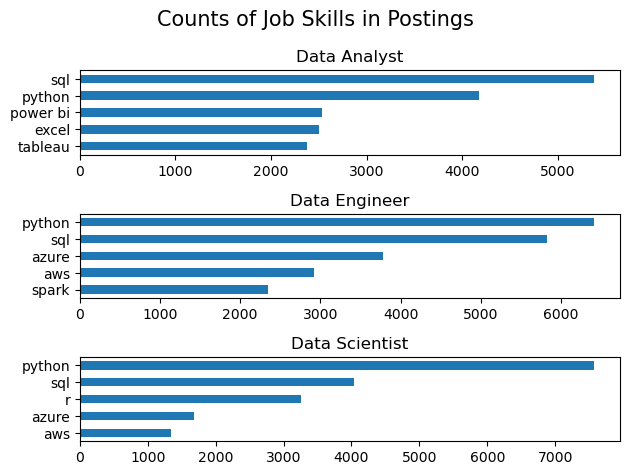

In [5]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh',x = 'job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
    ax[i].invert_yaxis()
fig.suptitle("Counts of Job Skills in Postings", fontsize=15)
fig.tight_layout()

    

In [6]:
df_job_title_count = df_Ger['job_title_short'].value_counts().reset_index(name='jobs_total')

In [7]:
df_skill_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skill_perc['skill_perc'] = df_skill_perc['skill_count'] / df_skill_perc['jobs_total'] * 100
df_skill_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_perc
0,python,Data Scientist,7576,12424,60.978751
1,python,Data Engineer,6416,12156,52.780520
2,sql,Data Engineer,5821,12156,47.885818
3,sql,Data Analyst,5379,12993,41.399215
4,python,Data Analyst,4170,12993,32.094205
...,...,...,...,...,...
1558,mlpack,Data Engineer,1,12156,0.008226
1559,monday.com,Business Analyst,1,2172,0.046041
1560,typescript,Senior Data Analyst,1,1961,0.050994
1561,mongo,Data Scientist,1,12424,0.008049


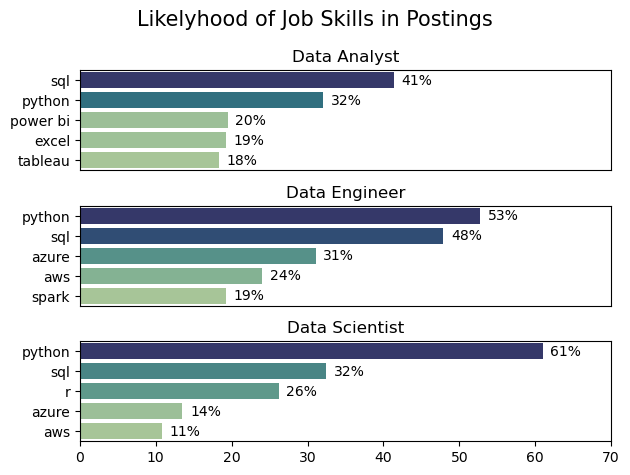

In [8]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head()
    sns.barplot(data=df_plot, x='skill_perc',  y='job_skills', ax=ax[i], hue='skill_count', palette='crest')
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,70)
    ax[i].set_title(job_title)
    for j, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+1, j, f'{v:.0f}%', va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])


fig.suptitle("Likelyhood of Job Skills in Postings", fontsize=15)
fig.tight_layout()

    